# =============================================================================
# CAPSTONE: AUTOMATED MALARIA DIAGNOSTICS (PYTORCH)
# =============================================================================

# 1. DATA ARCHITECTURE (From HW4 - Data Integrity)
# - NIH Dataset download via Kaggle
# - Split: 80% Train / 10% Val / 10% Test
# - Custom Transforms: ColorJitter (Microscope variations) & RandomRotation

# 2. MODEL BRAIN (From HW3 - ResNet Fine-Tuning)
# - Architecture: Pre-trained ResNet-50 (Transfer Learning)
# - Reason: Leverage spatial hierarchies learned from ImageNet
#model = models.resnet50(pretrained=True)
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, 2) # Binary: Parasitized vs. Uninfected

# 3. EVALUATION METRICS (From HW2 - Deep Interpretation)
# - Primary Metric: Recall (Sensitivity). 
# - Justification: In Malaria screening, a False Negative (missing a parasite) 
#   is a critical failure compared to a False Positive.
# - Tooling: Confusion Matrix & ROC-AUC Curve.

# 4. EXPLAINABILITY (The "Architect" Signature)
# - Implementation of Grad-CAM to highlight exactly where the model detects 
#   parasites in the blood cell.

**1.0: Project Header & Overview**

<div style="background-color: #1A1A1A; padding: 35px; border-radius: 10px; border-bottom: 10px solid #E02035; font-family: 'Segoe UI', sans-serif; color: white;">
    <h1 style="color: #E02035; margin-bottom: 0; text-transform: uppercase; letter-spacing: 3px; font-weight: 900;">
        Fanshawe College
    </h1>
    <h3 style="color: #ffffff; margin-top: 5px; font-weight: 300;">SCHOOL OF INFORMATION TECHNOLOGY</h3>
    <h3 style="color: #ffffff; margin-top: 5px; font-weight: 600;">INFO-6147: CAPSTONE PROJECT</h3>
    <hr style="border: 0.5px solid rgba(224,32,53,0.5);">
    <div style="display: flex; justify-content: space-between; font-size: 0.9em;">
        <div>
            <strong style="color: #E02035;">STUDENT NAME:</strong> Moses Mudiaga Effeyotah<br>
            <strong style="color: #E02035;">STUDENT ID:</strong> 1334675
        </div>
        <div style="text-align: right;">
            <strong style="color: #E02035;">PROJECT:</strong> Automated Malaria Diagnostics<br>
            <strong style="color: #E02035;">ARCHITECTURE:</strong> ResNet-50 with Grad-CAM
        </div>
    </div>
</div>


<div style="background-color: #1A1A1A; padding: 25px; border-left: 10px solid #E02035; font-family: 'Segoe UI', sans-serif; color: white; margin-top: 20px;">
<h2 style="color: #E02035; margin-top: 0; text-transform: uppercase; letter-spacing: 1px; font-weight: 800;">
Project Objectives
</h2>
<p style="font-size: 1.1em; line-height: 1.5;">
In clinical pathology, manual microscopic examination for Malaria is time-intensive and subject to human error. I have engineered a <b>Deep Learning Diagnostic Pipeline</b> to automate the detection of <i>Plasmodium</i> parasites in single-cell images.
</p>
<ul style="list-style-type: square; color: #E02035;">
<li><span style="color: white;"><b>1. Data Architecture:</b> I leverage the NIH dataset with an 80/10/10 split and custom <b>Color Palette</b> transforms to simulate microscope variance.</span></li>
<li><span style="color: white;"><b>2. Model Brain:</b> I fine-tune a pre-trained <b>ResNet-50</b>, utilizing deep spatial hierarchies learned from ImageNet.</span></li>
<li><span style="color: white;"><b>3. Evaluation Metrics:</b> I prioritize <b>Recall (Sensitivity)</b> to minimize False Negatives, which represent the highest clinical risk.</span></li>
<li><span style="color: white;"><b>4. Explainability:</b> I implement <b>Grad-CAM</b> to provide visual transparency for every diagnostic decision.</span></li>
</ul>
</div>

**1.0: Data Architecture & ETL**

<div style="background-color: #1A1A1A; padding: 25px; border-left: 10px solid #E02035; font-family: 'Segoe UI', sans-serif; color: white; margin-top: 20px;">
<h2 style="color: #E02035; margin-top: 0; text-transform: uppercase; letter-spacing: 1px; font-weight: 800;">
1.0 Data Integrity & ETL Pipeline
</h2>
<p style="font-size: 1.1em; line-height: 1.5;">
The <b>NIH Malaria Dataset</b> contains 27,558 cellular images. To ensure a robust training environment, I implemented a custom ETL (Extract, Transform, Load) pipeline to stage clean data and apply medical-grade transformations.
</p>
<p style="font-style: italic; color: #CCCCCC;">
<b>Transformation Rationale:</b> I applied <b>ColorJitter</b> and <b>RandomRotation</b> to simulate variance in microscope lighting and slide orientation. This forces the model to learn structural morphology rather than memorizing laboratory-specific color profiles.
</p>
</div>

In [ ]:
# 1.1: Imports and Environment Setup. 

import torch
import torch.nn as nn 
import torch.optim as optim 
from torchvision import datasets, transforms, models 
from torch.utils.data import DataLoader, random_split, Subset 
import matplotlib.pyplot as plt 
import numpy as np 
import os 
import shutil 
import kagglehub  

# Set Device (GPU if available) 
device = torch.device("cuda" if torch.cuda.is_available() else "cpu") 
print(f"🚀 Computation Device: {device}") 

# 1.1.1: ETL Staging (Nuke & Rebuild) 
print("Fetching dataset via Kagglehub...")
base_path = kagglehub.dataset_download("iarunava/cell-images-for-detecting-malaria") 
staging_dir = './clean_cell_images'

# The classes ('Parasitized', 'Uninfected') are inside the 'cell_images' subfolder
source_dir = None
for root, dirs, files in os.walk(base_path): 
    if 'Parasitized' in dirs and 'Uninfected' in dirs:
        data_dir = root
        break

# Clear the staging directory if it exists
if os.path.exists(staging_dir):
    shutil.rmtree(staging_dir)
os.makedirs(staging_dir)


print("ETL Pipeline: Extracting classes to staging area...")
shutil.copytree(os.path.join(data_dir, 'Parasitized'), os.path.join(staging_dir, 'Parasitized'))
shutil.copytree(os.path.join(data_dir, 'Uninfected'), os.path.join(staging_dir, 'Uninfected'))

data_dir = staging_dir
print(f"✅ Verified Training Classes: {os.listdir(data_dir)}")

# 1.1.2: Define the Transformations. 
# ResNet expects 224x224.
# Raw transforms just for initial visualization. 
raw_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])


# Define the "Medical" Transformations. 
# We add Jitter to simulate different microscope lighting. 

train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(20), # Cells can be oriented anywhere on the slide.
    transforms.ColorJitter(brightness=0.2, contrast = 0.2, saturation = 0.2), # Stain Variations.
    transforms.ToTensor(),
    transforms.Normalize(mean = [0.485, 0.456, 0.406], std = [0.229, 0.224, 0.225]) # ImageNet Standards. 
])

validation_test_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean = [0.485, 0.456, 0.406], std = [0.229, 0.224, 0.225])
])

print("✅ Transformations defined successfully.")



🚀 Computation Device: cuda
Fetching dataset via Kagglehub...
ETL Pipeline: Extracting classes to staging area...
✅ Verified Training Classes: ['Parasitized', 'Uninfected']
✅ Transformations defined successfully.


**Visualizing: Before & After**

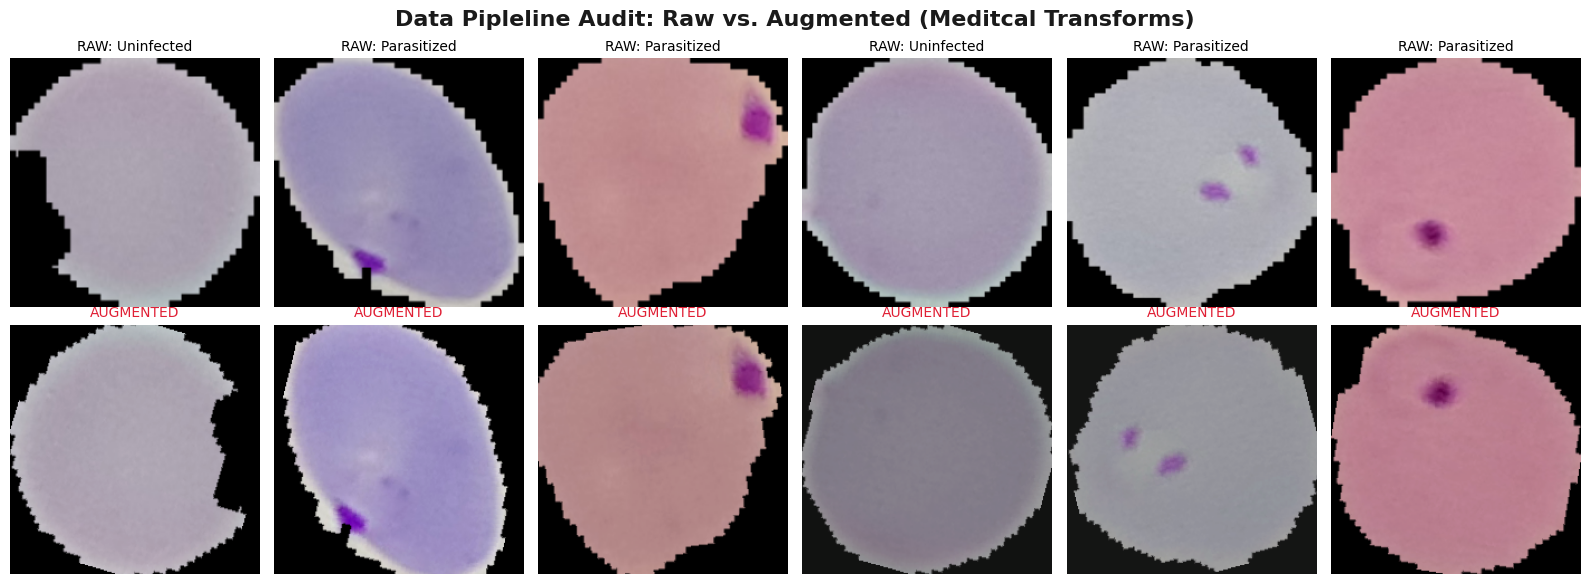

In [8]:
import torchvision.utils as vutils 

# Load raw datasets for visualization. 
raw_dataset = datasets.ImageFolder(root = data_dir, transform = raw_transforms)
aug_dataset = datasets.ImageFolder(root = data_dir, transform = train_transforms) 

# Un-normalize function for viewing augmented images. 
def unnormalize(img): 
    img = img.numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225]) 
    img = std * img + mean 
    img = np.clip(img, 0, 1) 
    return img 

# Get a batch of the images. 
torch.manual_seed(42) # For reproducibility. 
indices = torch.randperm(len(raw_dataset))[:6] 

fig, axes = plt.subplots(2, 6, figsize =(16, 6))
fig.suptitle("Data Pipleline Audit: Raw vs. Augmented (Meditcal Transforms)", fontsize = 16, fontweight = 'bold', color = '#1A1A1A')


for i, idx in enumerate(indices):
    # Raw Image. 
    raw_img, label = raw_dataset[idx]
    class_name = raw_dataset.classes[label]

    axes[0, i].imshow(raw_img.permute(1, 2, 0))
    axes[0, i].set_title(f"RAW: {class_name}", fontsize = 10)
    axes[0,i].axis("off") 

    # Augmented Image. 
    aug_img, _ = aug_dataset[idx] 
    axes[1, i].imshow(unnormalize(aug_img))
    axes[1, i].set_title("AUGMENTED", fontsize = 10, color = '#E02035') 
    axes[1, i].axis("off") 


plt.tight_layout()
plt.show() 


**The Data Splitting & Loader**

In [9]:
# Data Spliting & DataLoaders. 

from torch.utils.data import Subset, DataLoader 

print(" Engineering Data Splits (80% Train |  10% Validation |  10% Test)...")

# 1. Instantiate two versions of the dataset with different transforms. 
# One for training (with augmentations), one for val/test (clean). 
train_dataset_full = datasets.ImageFolder(root = data_dir, transform = train_transforms)
validation_test_dataset_full = datasets.ImageFolder(root = data_dir, transform = validation_test_transforms)

# 2. Calculate Split Sizes. 
total_images = len(train_dataset_full) 
train_size = int(0.8 * total_images) 
validation_size = int(0.1 * total_images) 
test_size = total_images - train_size - validation_size

# 3. Generate consistent random indices for the splits. 
generator = torch.Generator().manual_seed(42) # Seed for reproducibility. 
indices = torch.randperm(total_images, generator = generator).tolist() 

train_idx = indices[:train_size] 
validation_idx = indices[train_size: train_size + validation_size] 
test_idx = indices[train_size + validation_size :] 

# 4. Create the final Subsets applying the correct transforms. 
train_set = Subset(train_dataset_full, train_idx)
validation_set = Subset(validation_test_dataset_full, validation_idx)
test_set = Subset(validation_test_dataset_full, test_idx)

print(f"✅ Splits complete: {len(train_set)} Train | {len(validation_set)} Validation | {len(test_set)} Test")

# 5. Build the DataLoaders. 

train_loader = DataLoader(train_set, batch_size = 32, shuffle = True, num_workers = 2, pin_memory = True)
validation_loader = DataLoader(validation_set, batch_size = 32, shuffle = False, num_workers = 2, pin_memory = True) 
test_loader = DataLoader(test_set, batch_size = 32, shuffle = False, num_workers = 2, pin_memory = True)

print(" DataLoaders initialized and ready for the Neural Network.")



 Engineering Data Splits (80% Train |  10% Validation |  10% Test)...
✅ Splits complete: 22046 Train | 2755 Validation | 2757 Test
 DataLoaders initialized and ready for the Neural Network.


**3.0 Neural Network (ResNet-50 Transfer Learning)**

<div style="background-color: #1A1A1A; padding: 25px; border-left: 10px solid #E02035; font-family: 'Segoe UI', sans-serif; color: white; margin-top: 20px;">
<h2 style="color: #E02035; margin-top: 0; text-transform: uppercase; letter-spacing: 1px; font-weight: 800;">
3.0 Model Architecture: ResNet-50 Transfer Learning
</h2>
<p style="font-size: 1.1em; line-height: 1.5;">
I leveraged <b>ResNet-50</b>, utilizing skip connections to mitigate the vanishing gradient problem. The model is initialized with <b>ImageNet weights</b>, allowing us to utilize pre-learned spatial hierarchies. I replaced the final fully connected layer with a custom classification head tailored for binary Malaria diagnostics.
</p>
</div>

In [10]:
import torch.nn as nn 
import torch.optim as optim 
from torchvision import models 

print("🧠 Initializing ResNet-50 Deep Learning Architecture...")

# 1. Load Pre-Trained ResNet-50. (Using modern weights syntax) 
resnet_model = models.resnet50(weights = models.ResNet50_Weights.DEFAULT) 

# 2. Freeze the Core Convolutional Layers. 
# We tell PyTorch NOT to update the core brain. it already knows how to "see". 
for param in resnet_model.parameters():
    param.requires_grad = False

# 3. Modify the Classification Head. 
# Replace the final 1000-class output with a custom binary classifier. 
number_of_features = resnet_model.fc.in_features 

resnet_model.fc = nn.Sequential( 
    nn.Linear(number_of_features, 256),
    nn.ReLU(),
    nn.Dropout(0.5), # 50% Dropout to prevent overfitting (Crucial for Medical AI)
    nn.Linear(256, 2) # Output 2 classes (Parasitized, Uninfected) 
)

# 4. Move Model to the Computation Device (GPU)
resnet_model = resnet_model.to(device) 

# 5. Define the Optimization Engine & Loss Function. 
# CrossEntropyLoss is used for classification, and Adam is used to optimize the new FC layer. 

criterion = nn.CrossEntropyLoss() 
optimizer = optim.Adam(resnet_model.fc.parameters(), lr = 0.001) 

print("✅ ResNet- 50 Successfully Modified for Binary Medical Classification.")
print(f"✅ Model Deployed to: {device}") 

🧠 Initializing ResNet-50 Deep Learning Architecture...
✅ ResNet- 50 Successfully Modified for Binary Medical Classification.
✅ Model Deployed to: cuda


**4. The Training Engine**  

In [11]:
# Part 4: The PyTorch training Engine. 

import time
import copy

epochs = 5
best_accuracy = 0.0
best_model_wts = copy.deepcopy(resnet_model.state_dict())

# To keep track of our metrics for plotting later. 
history = {'train_loss': [], 'validation_loss': [], 'train_accuracy': [], 'validation_accuracy': []}

print("🚀 IGNITING TRAINING ENGINE...")
print("-" * 50)

start_time = time.time()

for epoch in range(epochs): 
    epoch_start = time.time() 
    print(f'Epoch {epoch+1}/{epochs}')

    # --------TRAINING PHASE ---------
    resnet_model.train() # Set model to training mode. 
    running_loss = 0.0
    running_corrects = 0

    for inputs, labels in train_loader:
        inputs = inputs.to(device) 
        labels = labels.to(device)

        optimizer.zero_grad() # Clear old graidents. 

        # Forward Pass. 
        outputs = resnet_model(inputs) 
        loss = criterion(outputs, labels)
        _, preds = torch.max(outputs, 1)

        # Backward Pass (Learn)
        loss.backward()
        optimizer.step() 

        running_loss += loss.item() * inputs.size(0)
        running_corrects += torch.sum(preds == labels.data)

    epoch_train_loss = running_loss / len(train_set)
    epoch_train_accuracy = running_corrects.double() / len(train_set) 


    # ---------------- VALIDATION PHASE ----------------
    resnet_model.eval() # Set model to evaluation mode. (turns off Dropout) 
    validation_loss = 0.0
    validation_corrects = 0

    # gradients are not needed for validation, it saves memory and speeds up the calculation. 

    with torch.no_grad():
        for inputs, labels in validation_loader: 
            inputs = inputs.to(device) 
            labels = labels.to(device)

            outputs = resnet_model(inputs) 
            loss = criterion(outputs, labels) 
            _, preds = torch.max(outputs, 1)

            validation_loss += loss.item() * inputs.size(0)
            validation_corrects += torch.sum(preds == labels.data) 


    epoch_validation_loss = validation_loss / len(validation_set) 
    epoch_validation_accuracy = validation_corrects.double() / len(validation_set) 

    # Save metrics for plotting. 
    history['train_loss'].append(epoch_train_loss) 
    history['validation_loss'].append(epoch_validation_loss)
    history['train_accuracy'].append(epoch_train_accuracy.item())
    history['validation_accuracy'].append(epoch_validation_accuracy.item())

    # Checkpoint: Save the best model. 
    if epoch_validation_accuracy > best_accuracy:
       best_accuracy = epoch_validation_accuracy
       best_model_wts = copy.deepcopy(resnet_model.state_dict())
       torch.save(resnet_model.state_dict(), 'best_malaria_resnet.pth') 
       checkpoint_message = "💾 [NEW BEST MODEL SAVED!]"
    else:
        checkpoint_message = ""

    epoch_time = time.time() - epoch_start 
    print(f"Train Loss: {epoch_train_loss:.4f} | Accuracy: {epoch_train_accuracy:.4f}")
    print(f"Validation Loss: {epoch_validation_loss:.4f} | Accuracy: {epoch_validation_accuracy:.4f} {checkpoint_message}")
    print(f"Time: {epoch_time:.0f}s")
    print("-" * 50)

# Load the best weights back into the model at the end. 
resnet_model.load_state_dict(best_model_wts) 
total_time = time.time() - start_time 
print(f'✅ Training Complete in {total_time // 60:.0f}m {total_time % 60:.0f}s')
print(f'🏆 Best Validation Accuracy: {best_accuracy:.4f}')



🚀 IGNITING TRAINING ENGINE...
--------------------------------------------------
Epoch 1/5
Train Loss: 0.2437 | Accuracy: 0.9052
Validation Loss: 0.1807 | Accuracy: 0.9347 💾 [NEW BEST MODEL SAVED!]
Time: 170s
--------------------------------------------------
Epoch 2/5
Train Loss: 0.1968 | Accuracy: 0.9262
Validation Loss: 0.1644 | Accuracy: 0.9430 💾 [NEW BEST MODEL SAVED!]
Time: 85s
--------------------------------------------------
Epoch 3/5
Train Loss: 0.1889 | Accuracy: 0.9306
Validation Loss: 0.1536 | Accuracy: 0.9456 💾 [NEW BEST MODEL SAVED!]
Time: 83s
--------------------------------------------------
Epoch 4/5
Train Loss: 0.1830 | Accuracy: 0.9313
Validation Loss: 0.1470 | Accuracy: 0.9477 💾 [NEW BEST MODEL SAVED!]
Time: 81s
--------------------------------------------------
Epoch 5/5
Train Loss: 0.1826 | Accuracy: 0.9324
Validation Loss: 0.1462 | Accuracy: 0.9470 
Time: 81s
--------------------------------------------------
✅ Training Complete in 8m 20s
🏆 Best Validation Accur

**Part 5: Performance & Clinical Evaluation.**

<div style="background-color: #1A1A1A; padding: 25px; border-left: 10px solid #E02035; font-family: 'Segoe UI', sans-serif; color: white;">
<h2 style="color: #E02035; margin-top: 0; text-transform: uppercase; letter-spacing: 1px; font-weight: 800;">
Clinical Evaluation Strategy
</h2>
<p>
I have designated <b>Recall (Sensitivity)</b> as the primary metric. In a clinical diagnostic setting, a False Negative is a critical failure that directly impacts patient safety. I will utilize a Confusion Matrix and ROC-AUC curves to interpret the model's reliability.
</p>
</div>

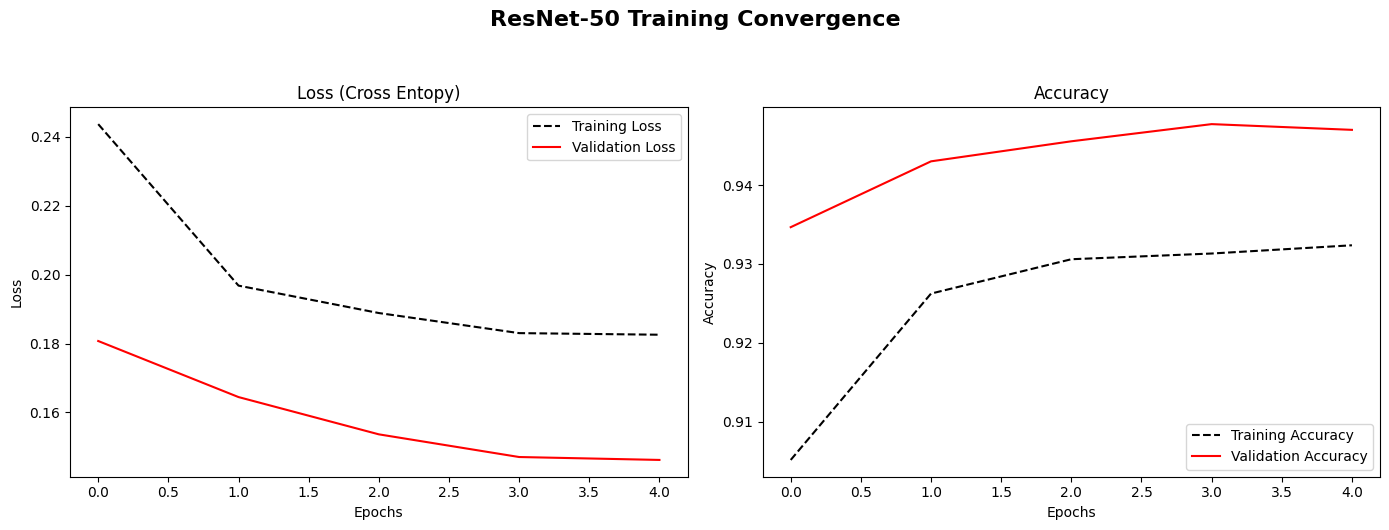

🔬 Initiating Clinical Evaluation on Unseen Test Set...
🏆 Final Test Set Accuracy: 0.9434
--------------------------------------------------


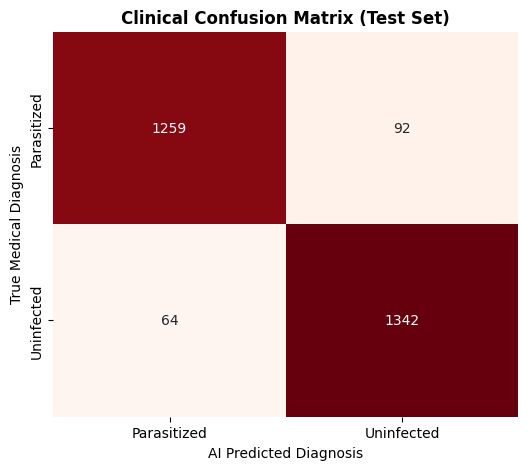

📋 CLINICAL CLASSIFICATION REPORT:
              precision    recall  f1-score   support

 Parasitized       0.95      0.93      0.94      1351
  Uninfected       0.94      0.95      0.95      1406

    accuracy                           0.94      2757
   macro avg       0.94      0.94      0.94      2757
weighted avg       0.94      0.94      0.94      2757

📊 Calculating ROC-AUC Clinical Metrics...


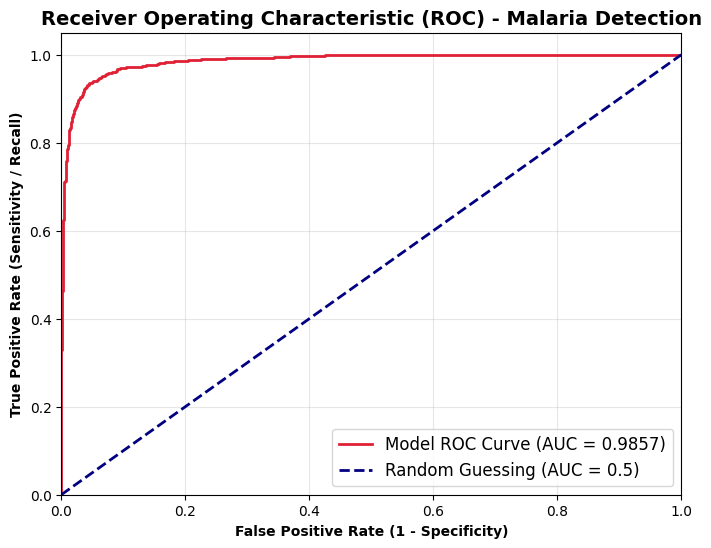

🏆 Final Area Under the Curve (AUC): 0.9857


In [12]:
# 5: Performance Visualization & Clinical Evaluation. 

import matplotlib.pyplot as plt 
import seaborn as sns 
from sklearn.metrics import confusion_matrix, classification_report 
import numpy as np 
import torch 

# 5.1: Visualize Training Convergence. 
fig, (ax1, ax2) = plt.subplots(1, 2, figsize = (14, 5))
fig.suptitle("ResNet-50 Training Convergence", fontsize = 16, fontweight = 'bold', y = 1.05)

# Loss Curve. 
ax1.plot(history['train_loss'], 'k--', label = 'Training Loss')
ax1.plot(history['validation_loss'], 'r-', label = 'Validation Loss')
ax1.set_title('Loss (Cross Entopy)') 
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Loss')
ax1.legend() 

# Accuracy Curve. 
ax2.plot(history['train_accuracy'], 'k--', label = 'Training Accuracy')
ax2.plot(history['validation_accuracy'], 'r-', label = 'Validation Accuracy')
ax2.set_title('Accuracy')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Accuracy')
ax2.legend()

plt.tight_layout()
plt.show() 

# 5.2 Evaluation on Unseen Test Set. 

print("🔬 Initiating Clinical Evaluation on Unseen Test Set...")
resnet_model.eval() # Ensure Dropout is off. 
test_corrects = 0
all_predictions = []
all_labels = []

# Forward pass on the Test Loader. 
with torch.no_grad():
    for inputs, labels in test_loader: 
        inputs = inputs.to(device)
        labels = labels.to(device) 

        outputs = resnet_model(inputs) 
        _, predictions = torch.max(outputs, 1)

        test_corrects += torch.sum(predictions == labels.data)

        all_predictions.extend(predictions.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

test_accuracy = test_corrects.double() / len(test_set)
print(f"🏆 Final Test Set Accuracy: {test_accuracy:.4f}")
print("-" * 50)

# 5.3: The Confusion Matrix & Recall Audit. 

# Calculate Confusion Matrix. 

confusion_matrix = confusion_matrix(all_labels, all_predictions)

plt.figure(figsize = (6, 5))
sns.heatmap(confusion_matrix, annot = True, fmt = 'd', cmap = 'Reds', cbar = False,
            xticklabels = ['Parasitized', 'Uninfected'],
            yticklabels = ['Parasitized', 'Uninfected'])

plt.title('Clinical Confusion Matrix (Test Set)', fontweight = 'bold')
plt.ylabel('True Medical Diagnosis')
plt.xlabel('AI Predicted Diagnosis')
plt.show() 

# Print the Clinical Classification Report. 
print("📋 CLINICAL CLASSIFICATION REPORT:")
print(classification_report(all_labels, all_predictions, target_names = ['Parasitized', 'Uninfected']))

# 5.4 ROC-AUC Curve
from sklearn.metrics import roc_curve, auc
import torch.nn.functional as F 

print("📊 Calculating ROC-AUC Clinical Metrics...")

resnet_model.eval()
all_probs = []
all_targets = []

# Forward pass to get raw probabilities. 
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        labels = labels.to(device) 

        outputs = resnet_model(inputs)
        # Apply softmax to get probablities (0 to 1) 
        probs = F.softmax(outputs, dim =1) 

        # Get the probability of the 'Parasitized'class (Class 0)
        all_probs.extend(probs[:, 0].cpu().numpy())
        all_targets.extend(labels.cpu().numpy())

# Calculate False Positive rate, True Positive Rate, and AUC. 
# Because 'Parasitized' is mathematically class 0 in our dataset, me set pos_label = 0
fpr, tpr, thresholds = roc_curve(all_targets, all_probs, pos_label = 0) 
roc_auc = auc(fpr, tpr) 

# Render the ROC Curve. 

plt.figure(figsize = (8, 6))
plt.plot(fpr, tpr, color = '#E02035', lw =2, label = f'Model ROC Curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color = 'navy', lw = 2, linestyle = '--', label = 'Random Guessing (AUC = 0.5)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)', fontweight = 'bold')
plt.ylabel('True Positive Rate (Sensitivity / Recall)', fontweight = 'bold')
plt.title('Receiver Operating Characteristic (ROC) - Malaria Detection', fontsize = 14, fontweight = 'bold')
plt.legend(loc = "lower right", fontsize = 12)
plt.grid(alpha = 0.3) 
plt.show() 

print(f"🏆 Final Area Under the Curve (AUC): {roc_auc:.4f}")


**6: Algorithmic Explainability (Grad-CAM)**

<div style="background-color: #1A1A1A; padding: 25px; border-left: 10px solid #E02035; font-family: 'Segoe UI', sans-serif; color: white; margin-top: 20px;">
<h2 style="color: #E02035; margin-top: 0; text-transform: uppercase; letter-spacing: 1px; font-weight: 800;">
Algorithmic Transparency via Grad-CAM
</h2>
<p>
To ensure clinical accountability, I implement <b>Grad-CAM (Gradient-weighted Class Activation Mapping)</b>. This provides a visual overlay, highlighting the precise cellular regions that influenced my model's diagnostic conclusion.
</p>
</div>

🔍 Initializing grad-CAM Visualizer...


C:\Users\moeff\AppData\Local\Temp\ipykernel_28928\863871523.py:86: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  jet = cm.get_cmap('jet')


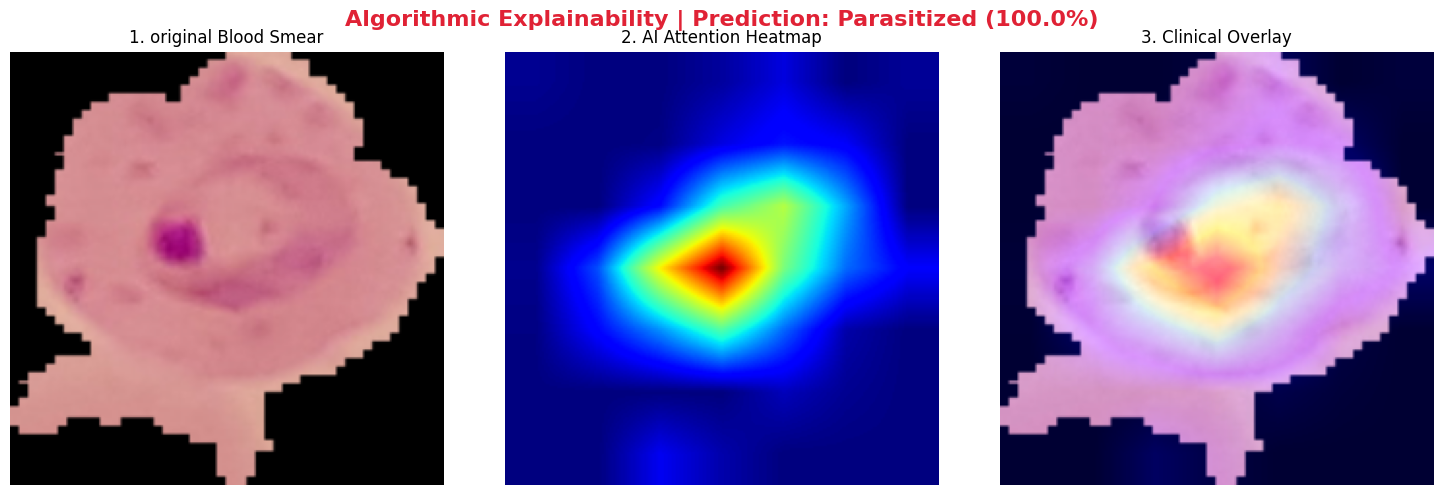

In [13]:
# 6. Algorithmic Transparency (Grad-CAM Explainability) 

import torch.nn.functional as F
import matplotlib.cm as cm 
import numpy as np 
import matplotlib.pyplot as plt
import torch
import cv2

print("🔍 Initializing grad-CAM Visualizer...")

# 6.1. Define the grad-CAM extraction logic. 
class ResNetGradCAM: 
    def __init__(self, model, target_layer):
        self.model = model 
        self.target_layer = target_layer 
        self.gradients = None
        self.activations = None 

        # Hooks to grab the gradients and activations during the forward/backward pass. 
        target_layer.register_forward_hook(self.save_activation)
        target_layer.register_full_backward_hook(self.save_gradient) 

    def save_activation(self, module, input, output):
        self.activations = output 

    def save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0]

    def generate_heatmap(self, input_image, class_idx):
        model_output = self.model(input_image)
        self.model.zero_grad() 

        target = model_output[:, class_idx]
        target.backward() 

        # Calculate weights and build heatmap. 
        gradients = self.gradients.cpu().data.numpy()[0]
        activations = self.activations.cpu().data.numpy()[0]
        weights = np.mean(gradients, axis = (1, 2))

        cam = np.zeros(activations.shape[1:], dtype = np.float32)
        for i, w in enumerate(weights):
            cam += w * activations[i]

        cam = np.maximum(cam, 0) # Apply ReLU. 
        import cv2 # Local import for resizing. 
        cam = cv2.resize(cam, (224, 224))
        cam = cam - np.min(cam)
        cam = cam / np.max(cam)
        return cam 

# 6.2 Attach Grad-CAM to the final convolutional layer of ResNet50. 
grad_cam = ResNetGradCAM(resnet_model, resnet_model.layer4[-1])

# 6.3 Fetch a 'Parsitized' test image. 
resnet_model.eval() 
for inputs, labels in test_loader: 
    # Find an image where the true label is 'Parasitized' (Class 0)
    idx = (labels == 0).nonzero(as_tuple = True)[0]
    if len(idx) > 0: 
        img_tensor = inputs[idx[0]].unsqueeze(0).to(device)
        img_tensor.requires_grad_()

        true_label = labels[idx[0]].item()
        break 

# 6.4. Generate Ai Prediction & Heatmap. 
pred_probs = torch.softmax(resnet_model(img_tensor), dim = 1)
pred_class = torch.argmax(pred_probs).item()
confidence = pred_probs[0][pred_class].item() * 100

heatmap = grad_cam.generate_heatmap(img_tensor, pred_class)

# 6.5. Format the imagery for clinical display,
def format_image(tensor):
    img = tensor.cpu().squeeze().detach().numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img = std * img + mean
    return np.clip(img, 0, 1) 

original_img = format_image(img_tensor)

# Use matplotlib to create the color overlay safely. 
jet = cm.get_cmap('jet') 
heatmap_colored = jet(heatmap)[:, :, :3] # RGB Channels. 
superimposed_img = heatmap_colored * 0.4 + original_img
superimposed_img = np.clip(superimposed_img, 0, 1) 

# 6.6. Render the Report. 
fig, axes = plt.subplots(1, 3, figsize = (15, 5))
pred_name = 'Parasitized' if pred_class == 0 else 'Uninfected' 

fig.suptitle(f"Algorithmic Explainability | Prediction: {pred_name} ({confidence:.1f}%)", fontsize = 16, fontweight = 'bold', color = '#E02235') 

axes[0].imshow(original_img) 
axes[0].set_title("1. original Blood Smear")
axes[0].axis('off') 

axes[1].imshow(heatmap, cmap = 'jet')
axes[1].set_title("2. AI Attention Heatmap")
axes[1].axis('off')

axes[2].imshow(superimposed_img, cmap = 'jet')
axes[2].set_title("3. Clinical Overlay")
axes[2].axis('off')

plt.tight_layout()
plt.show()


In [14]:
#pip install streamlit google-generativeai